In [ ]:
pip install opencv-python matplotlib numpy

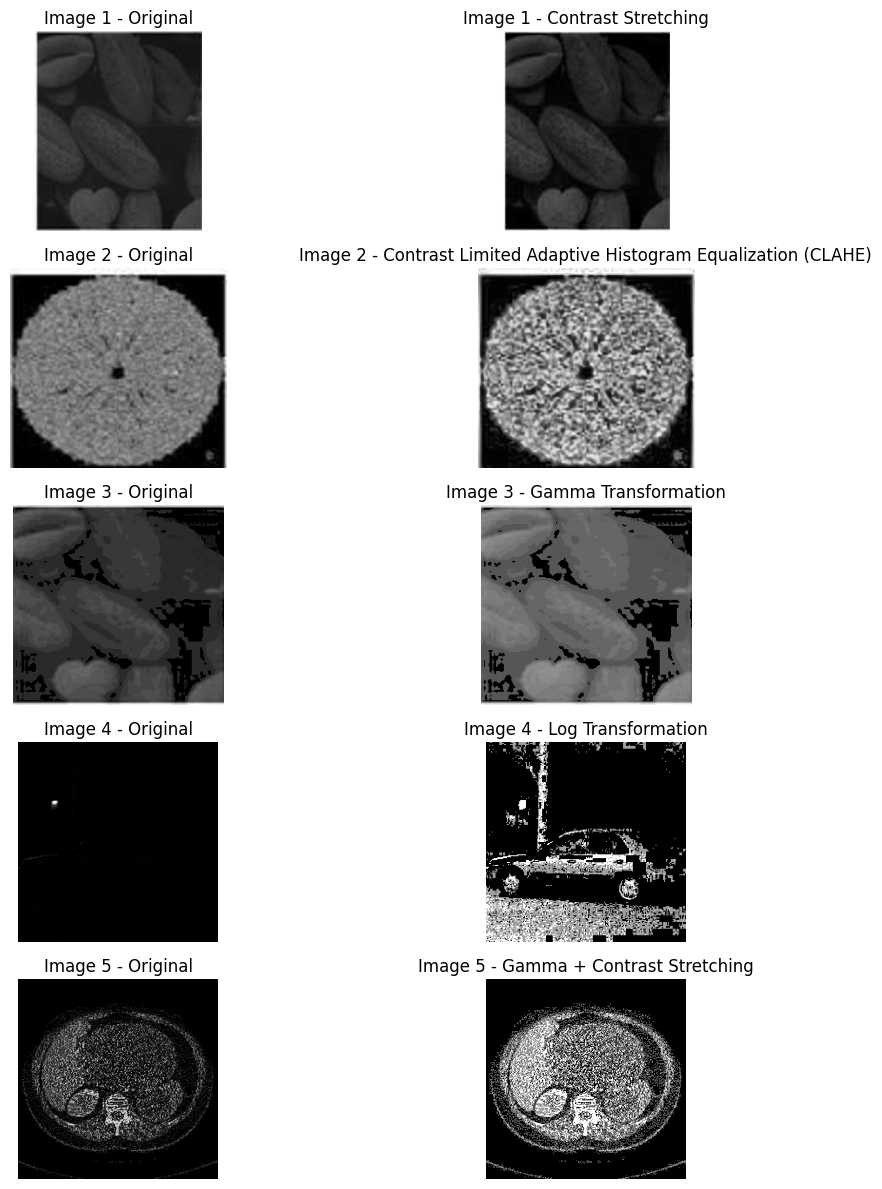

In [40]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

#contrast stretching
# def contrast_stretching(img):
#     r_min = np.min(img)
#     r_max = np.max(img)

#     stretched = ((img - r_min) / (r_max - r_min)) * 255

#     return np.uint8(stretched)
def contrast_stretching(img):
    low = np.percentile(img, 2)
    high = np.percentile(img, 98)

    stretched = (img - low) / (high - low) * 255
    stretched = np.clip(stretched, 0, 255)

    return np.uint8(stretched)

#gamma
def gamma_transform(img, gamma):
    # Normalize image to 0-1
    normalized = img / 255.0

    # Gamma transformation
    corrected = np.power(normalized, gamma)

    # Convert back to 0-255
    corrected = corrected * 255

    return np.uint8(corrected)


#Log Transformation
def log_transform(img):
    # Convert to float
    img_float = img.astype(np.float32)

    # c is selected so that output lies in 0-255
    c = 255 / np.log(1 + np.max(img_float))

    log_img = c * np.log(1 + img_float)

    return np.uint8(log_img)



# Histogram Equalization
def histogram_equalization(img):
     return cv2.equalizeHist(img)
# clahe = cv2.createCLAHE(
#     clipLimit=2.0,
#     tileGridSize=(8, 8)
# )

# enhanced2 = clahe.apply(img2)



img1 = cv2.imread("pic1.png", cv2.IMREAD_GRAYSCALE)
img2 = cv2.imread("pic2.png", cv2.IMREAD_GRAYSCALE)
img3 = cv2.imread("pic3.png", cv2.IMREAD_GRAYSCALE)
img4 = cv2.imread("pic4.png", cv2.IMREAD_GRAYSCALE)
img5 = cv2.imread("pic5.png", cv2.IMREAD_GRAYSCALE)


# Image 1 - Contrast Stretching
enhanced1 = contrast_stretching(img1)

clahe = cv2.createCLAHE(
    clipLimit=3.0,
    tileGridSize=(8, 8)
)

enhanced2 = clahe.apply(img2)
# Image 2 - Histogram Equalization
#enhanced2 = histogram_equalization(img2)


# Image 3 - Gamma Transformation
enhanced3 = gamma_transform(img3, 0.6)


# Image 4 - Log Transformation
# enhanced4 = log_transform(img4)
log4 = log_transform(img4)
enhanced4 = contrast_stretching(log4)

# Image 5 - Gamma + Contrast Stretching
gamma5 = gamma_transform(img5, 0.6)
enhanced5 = contrast_stretching(gamma5)



images = [
    img1, enhanced1,
    img2, enhanced2,
    img3, enhanced3,
    img4, enhanced4,
    img5, enhanced5
]

titles = [
    "Image 1 - Original",
    "Image 1 - Contrast Stretching",

    "Image 2 - Original",
    "Image 2 - Contrast Limited Adaptive Histogram Equalization (CLAHE)",

    "Image 3 - Original",
    "Image 3 - Gamma Transformation",

    "Image 4 - Original",
    "Image 4 - Log Transformation",

    "Image 5 - Original",
    "Image 5 - Gamma + Contrast Stretching"
]


plt.figure(figsize=(12, 12))

for i in range(10):
    plt.subplot(5, 2, i + 1)
    plt.imshow(images[i], cmap="gray")
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()